# Install Library 

In [1]:
!pip install ultralytics

In [ ]:
# Cell - ถอน PyTorch เก่าออกก่อน แล้วติดตั้งใหม่เป็น CUDA version

# !pip uninstall torch torchvision torchaudio -y

In [2]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124


# Import

In [25]:
from ultralytics import YOLO
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
import math
import matplotlib.image as mpimg


# Check GPU

In [4]:
# เช็คก่อนว่ามี GPU มั้ย
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))

GPU available: True
GPU name: NVIDIA GeForce RTX 4060 Ti


In [6]:
# โหลด pre-trained model
model = YOLO('yolov8s.pt')

# Fine-tune
model.train(
    data='koi_data/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    pretrained=True,
    device=0,           # ใช้ GPU ตัวแรก (ถ้ามีหลายตัวใส่ [0,1])
    workers=4,          # จำนวน CPU cores ช่วยโหลดข้อมูล
    project='koi-detect',
    name='exp1',
    save=True,
    plots=True          # save กราฟ results.png
)

Ultralytics 8.4.19  Python-3.12.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=koi_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp12, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspectiv

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000027A830D1580>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

# Test + Visualize

In [7]:
model = YOLO('runs/detect/koi-detect/exp12/weights/best.pt')

# Test กับ test set
results = model.val(data='koi_data/data.yaml', split='test')

Ultralytics 8.4.19  Python-3.12.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8188MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 390.895.2 MB/s, size: 55.4 KB)
val: Scanning D:\normal_file\coder\PSU-Code\Sophomore-Project\module\Aj_Nikom\project\koi_data\test\labels... 105 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 105/105 437.5it/s 0.2s1s
val: New cache created: D:\normal_file\coder\PSU-Code\Sophomore-Project\module\Aj_Nikom\project\koi_data\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.7it/s 2.6s0.3ss
                   all        105       4581      0.966      0.942      0.988      0.957
Speed: 2.7ms preprocess, 7.0ms inference, 0.0ms loss, 9.7ms postprocess per image
Results saved to D:\normal_file\coder\PSU-Code\Sophomore-Project\module\Aj_Nikom\project\runs\detect\val


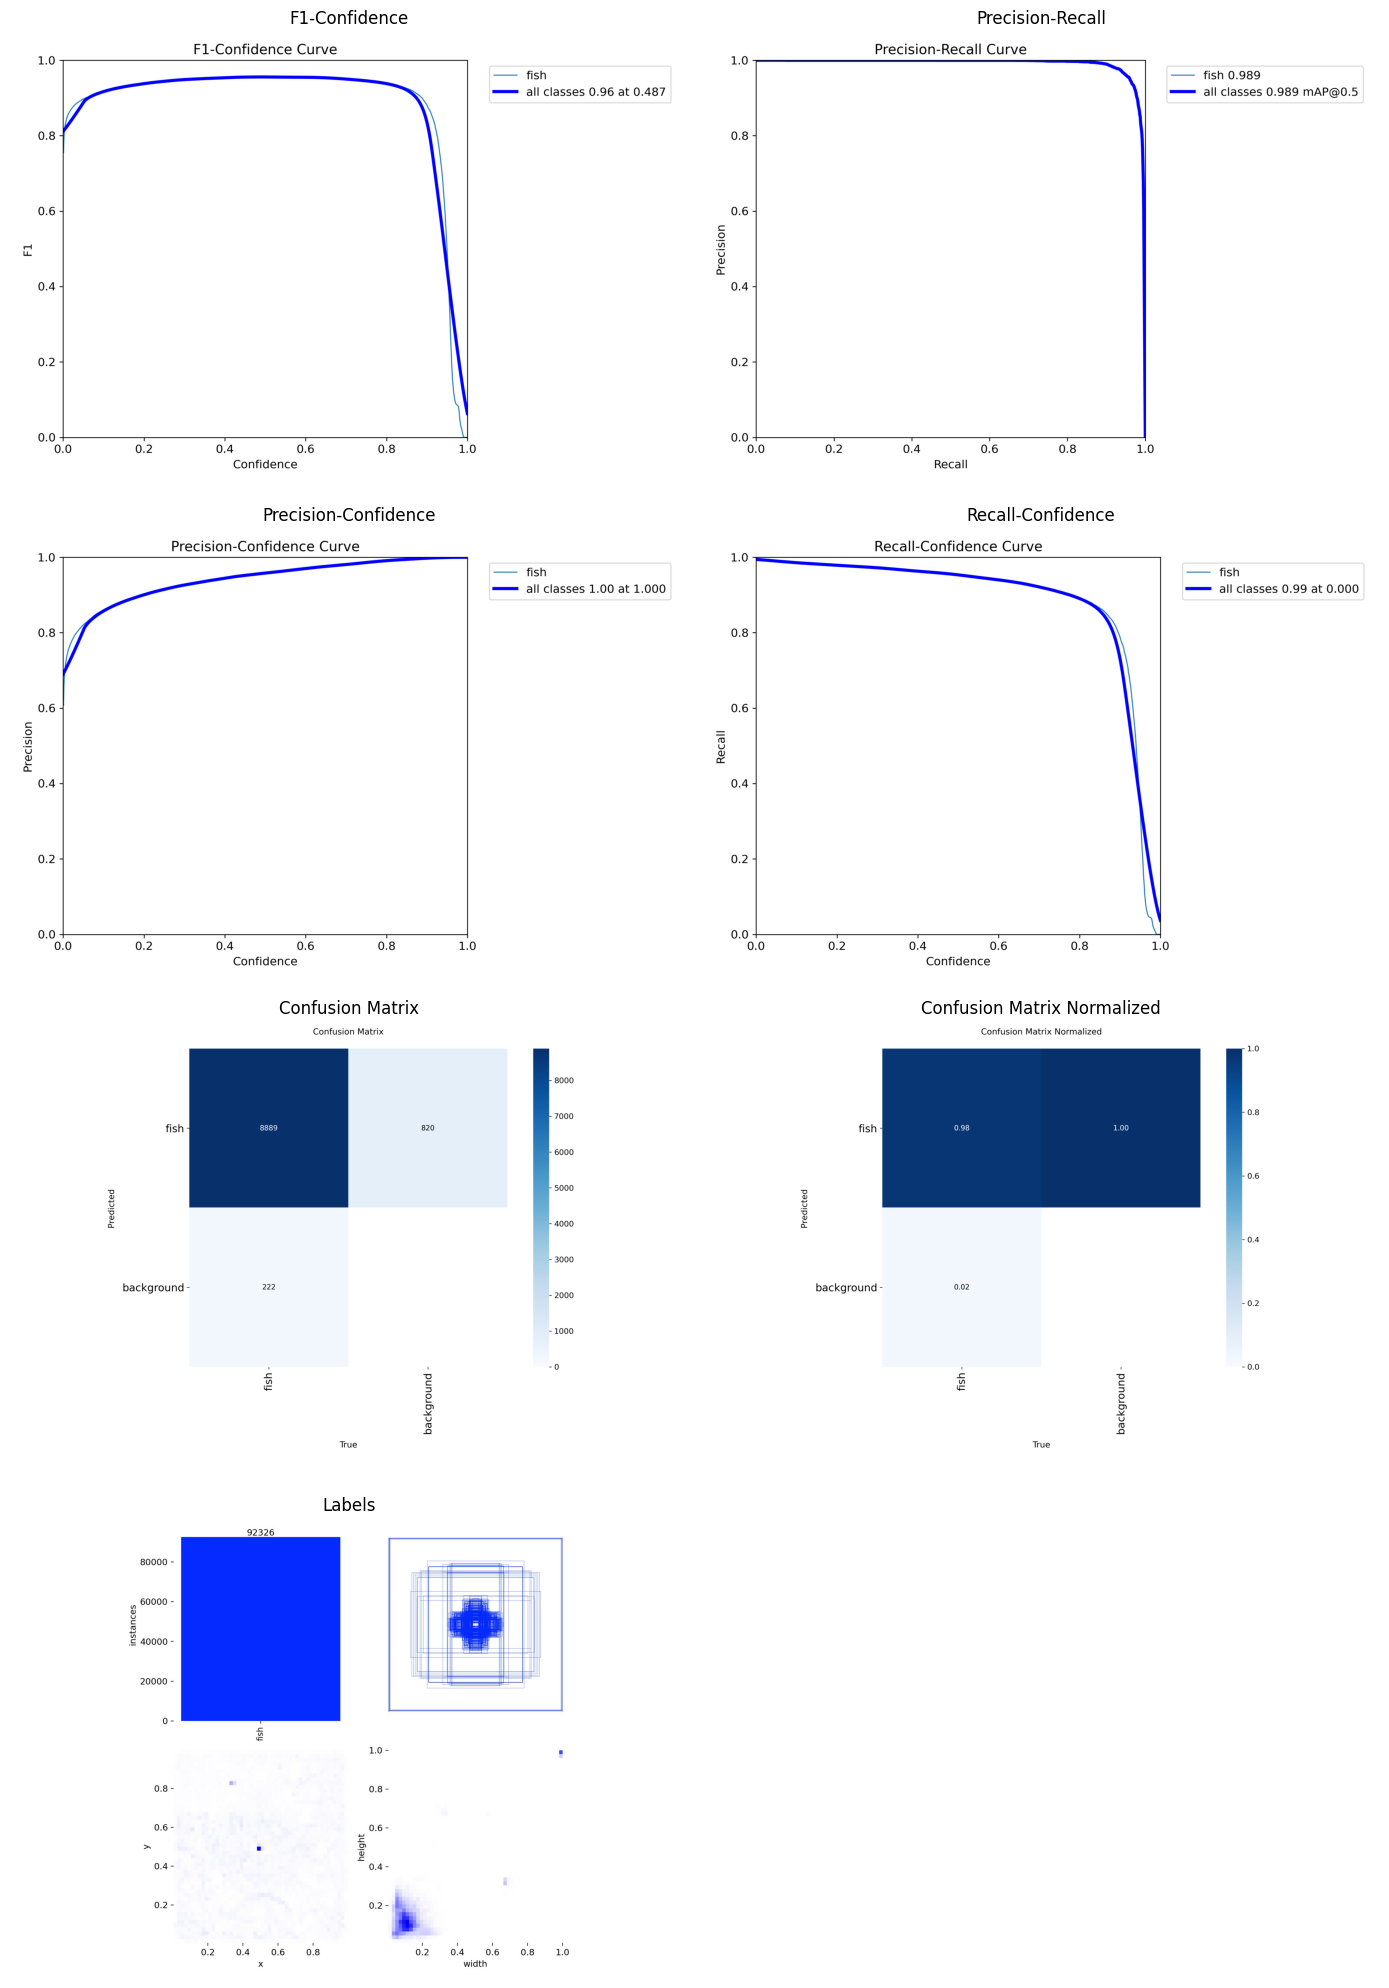

In [ ]:
%matplotlib inline

base = r'D:/normal_file/coder/PSU-Code/Sophomore-Project/module/Aj_Nikom/project/runs/detect/koi-detect/exp12'

images = {
    'F1-Confidence': f'{base}/BoxF1_curve.png',
    'Precision-Recall': f'{base}/BoxPR_curve.png',
    'Precision-Confidence': f'{base}/BoxP_curve.png',
    'Recall-Confidence': f'{base}/BoxR_curve.png',
    'Confusion Matrix': f'{base}/confusion_matrix.png',
    'Confusion Matrix Normalized': f'{base}/confusion_matrix_normalized.png',
    'Labels': f'{base}/labels.jpg',
}

fig, axes = plt.subplots(4, 2, figsize=(14, 20))

for ax, (title, path) in zip(axes.flatten(), images.items()):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# ปิด axis ที่เหลือ (มี 8 grid แต่รูปแค่ 7)
axes[3][1].axis('off')

plt.tight_layout()
plt.show()

# Test with real data


image 1/1 D:\normal_file\coder\PSU-Code\Sophomore-Project\module\Aj_Nikom\project\real_data\realcrop.png: 640x512 8 fishs, 44.9ms
Speed: 1.9ms preprocess, 44.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 512)
detect ได้ 8 ตัว


C:\Users\Saeb0m\AppData\Local\Temp\ipykernel_27880\1200636900.py:46: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Saeb0m\AppData\Local\Temp\ipykernel_27880\1200636900.py:46: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Saeb0m\AppData\Local\Temp\ipykernel_27880\1200636900.py:46: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Saeb0m\anaconda3\envs\yolo-cv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Saeb0m\anaconda3\envs\yolo-cv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Saeb0m\anaconda3

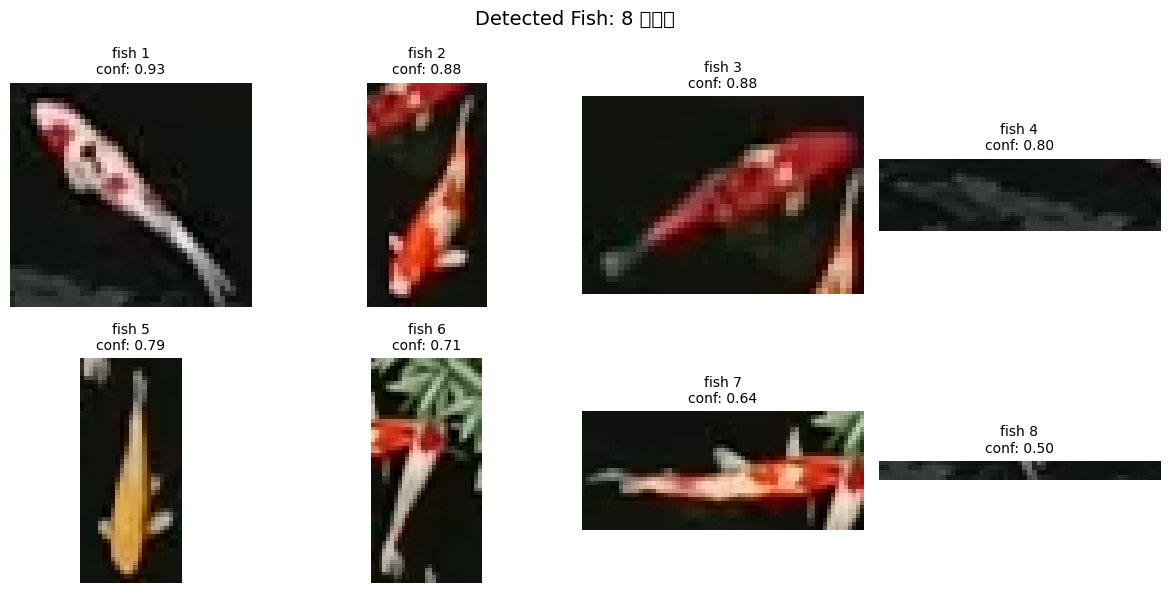

In [ ]:
model = YOLO(r'D:/normal_file/coder/PSU-Code/Sophomore-Project/module/Aj_Nikom/project/runs/detect/koi-detect/exp12/weights/best.pt')

results = model.predict(
    source=r'D:/normal_file/coder/PSU-Code/Sophomore-Project/module/Aj_Nikom/project/real_data/realcrop.png',
    conf=0.5,
    save=False,
    show=False
)

# Crop ปลาแต่ละตัว
img = cv2.imread(r'D:/normal_file/coder/PSU-Code/Sophomore-Project/module/Aj_Nikom/project/real_data/realcrop.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

crops = []
for i, box in enumerate(results[0].boxes.xyxy):
    x1, y1, x2, y2 = map(int, box)
    conf = float(results[0].boxes.conf[i])
    crop = img_rgb[y1:y2, x1:x2]
    crops.append((crop, conf))

print(f'detect ได้ {len(crops)} ตัว')

# วางเป็นตาราง
cols = 4
rows = math.ceil(len(crops) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

for i, (crop, conf) in enumerate(crops):
    axes[i].imshow(crop)
    axes[i].set_title(f'fish {i+1}\nconf: {conf:.2f}', fontsize=10)
    axes[i].axis('off')

# ปิด axes ที่เหลือ
for j in range(len(crops), len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Detected Fish: {len(crops)} ตัว', fontsize=14)
plt.tight_layout()
plt.show()

In [40]:
model = YOLO(r'D:/normal_file/coder/PSU-Code/Sophomore-Project/module/Aj_Nikom/project/runs/detect/koi-detect/exp12/weights/best.pt')
img_path = 'D:/normal_file/coder/PSU-Code/Sophomore-Project/module/Aj_Nikom/project/real_data/realcrop.png'

detect ได้ 8 ตัว


C:\Users\Saeb0m\AppData\Local\Temp\ipykernel_27880\2556100160.py:55: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Saeb0m\AppData\Local\Temp\ipykernel_27880\2556100160.py:55: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Saeb0m\AppData\Local\Temp\ipykernel_27880\2556100160.py:55: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


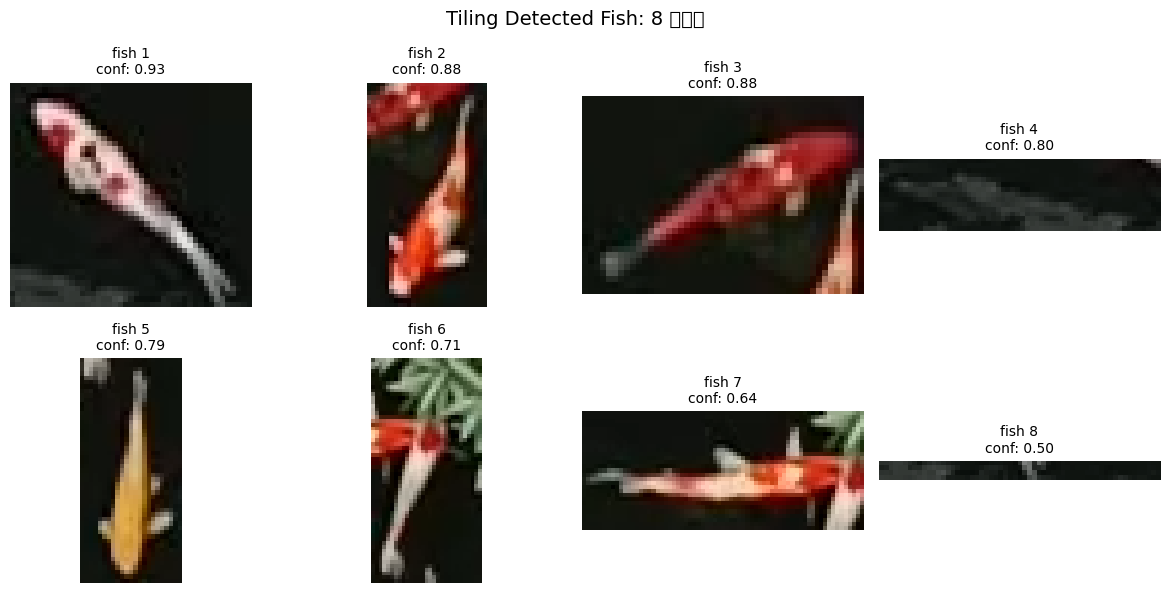

In [41]:
def detect_with_tiling(image_path, tile_size=640, overlap=0.2):
    img = cv2.imread(image_path)
    h, w = img.shape[:2]
    step = int(tile_size * (1 - overlap))
    
    all_boxes = []
    all_confs = []
    
    for y in range(0, h, step):
        for x in range(0, w, step):
            x2 = min(x + tile_size, w)
            y2 = min(y + tile_size, h)
            tile = img[y:y2, x:x2]
            
            results = model.predict(tile, conf=0.5, verbose=False)
            
            for i, box in enumerate(results[0].boxes.xyxy):
                bx1, by1, bx2, by2 = map(int, box)
                conf = float(results[0].boxes.conf[i])
                all_boxes.append((bx1+x, by1+y, bx2+x, by2+y))
                all_confs.append(conf)
    
    return all_boxes, all_confs

boxes, confs = detect_with_tiling(img_path)
print(f'detect ได้ {len(boxes)} ตัว')

# crop แต่ละตัว
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

crops = []
for i, (box, conf) in enumerate(zip(boxes, confs)):
    x1, y1, x2, y2 = box
    crop = img_rgb[y1:y2, x1:x2]
    if crop.size > 0:
        crops.append((crop, conf))

# โชว์ตาราง
cols = 4
rows = math.ceil(len(crops) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

for i, (crop, conf) in enumerate(crops):
    axes[i].imshow(crop)
    axes[i].set_title(f'fish {i+1}\nconf: {conf:.2f}', fontsize=10)
    axes[i].axis('off')

for j in range(len(crops), len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Tiling Detected Fish: {len(crops)} ตัว', fontsize=14)
plt.tight_layout()
plt.show()

In [47]:
img_path_2 = 'D:/normal_file/coder/PSU-Code/Sophomore-Project/module/Aj_Nikom/project/real_data/realcrop2.png'

detect ได้ 8 ตัว


C:\Users\Saeb0m\AppData\Local\Temp\ipykernel_27880\20300613.py:31: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Saeb0m\AppData\Local\Temp\ipykernel_27880\20300613.py:31: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Saeb0m\AppData\Local\Temp\ipykernel_27880\20300613.py:31: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


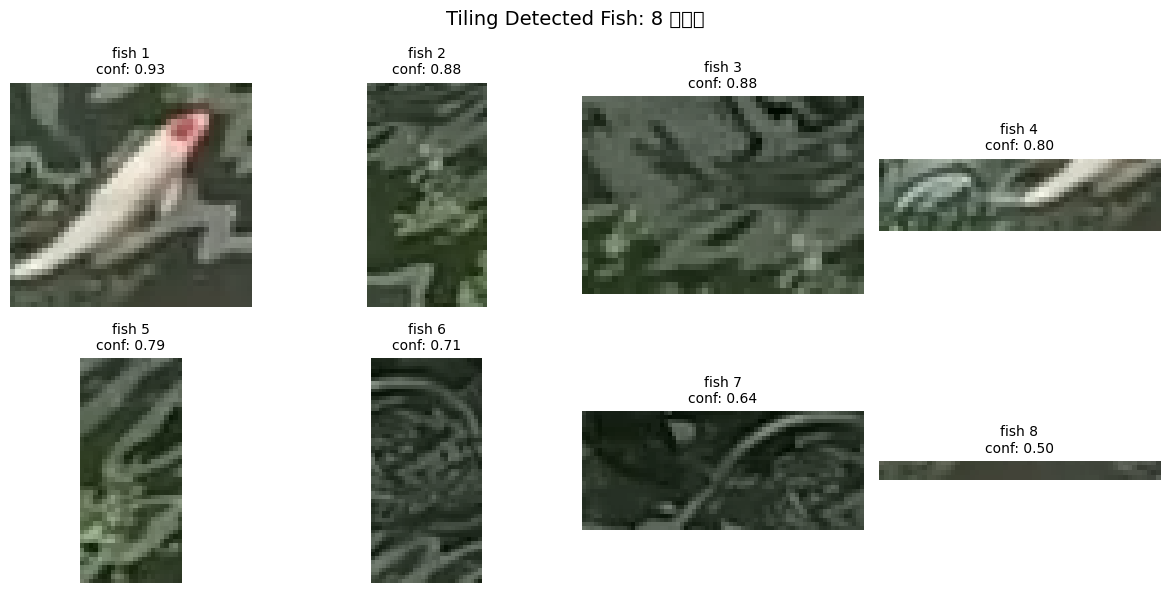

In [48]:
boxes, confs = detect_with_tiling(img_path)
print(f'detect ได้ {len(boxes)} ตัว')

# crop แต่ละตัว
img = cv2.imread(img_path_2)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

crops = []
for i, (box, conf) in enumerate(zip(boxes, confs)):
    x1, y1, x2, y2 = box
    crop = img_rgb[y1:y2, x1:x2]
    if crop.size > 0:
        crops.append((crop, conf))

# โชว์ตาราง
cols = 4
rows = math.ceil(len(crops) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

for i, (crop, conf) in enumerate(crops):
    axes[i].imshow(crop)
    axes[i].set_title(f'fish {i+1}\nconf: {conf:.2f}', fontsize=10)
    axes[i].axis('off')

for j in range(len(crops), len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Tiling Detected Fish: {len(crops)} ตัว', fontsize=14)
plt.tight_layout()
plt.show()